In [1]:
import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error

model_data = pd.read_csv(
    r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\data\processed\model_sample_cpi_wpi.csv",
    parse_dates=["date"]
)

model_data = (
    model_data
    .sort_values("date")
    .reset_index(drop=True)
)

display(model_data.head())

,date,cpi_combined,cpi_yoy,wpi_all,wpi_primary,wpi_fuel,wpi_manufacturing,wpi_all_yoy,wpi_primary_yoy,wpi_fuel_yoy,wpi_manufacturing_yoy,output_ppi,output_ppi_yoy
0,2024-04-01,186.7,4.828748,99.9,108.8,92.0,98.5,0.909091,6.666667,-2.127660,-0.605449,99.7,0.605449
1,2024-05-01,187.7,4.801787,100.4,110.1,91.7,98.9,1.825558,7.624633,0.328228,0.000000,100.1,1.521298
2,2024-06-01,190.2,5.082873,100.7,111.8,89.9,99.1,2.441506,8.228461,-0.662983,0.916497,100.4,2.240326
3,2024-07-01,193.0,3.596350,101.0,113.1,91.2,98.8,1.917255,4.819277,0.662252,1.022495,100.8,1.715439
4,2024-08-01,193.0,3.651987,100.8,113.8,90.9,98.4,1.306533,5.370370,-0.980392,0.305810,100.7,1.307847


In [2]:
y = (
    model_data[
        ["date", "cpi_yoy"]
    ]
    .dropna()
    .set_index("date")["cpi_yoy"]
)

print("Observations:", len(y))
print("Start:", y.index.min())
print("End:", y.index.max())

Observations: 28
Start: 2024-04-01 00:00:00
End: 2026-07-01 00:00:00


In [3]:
def walk_forward_arima(
    series,
    order,
    initial_window=60
):
    
    actuals = []
    forecasts = []
    forecast_dates = []

    for i in range(
        initial_window,
        len(series)
    ):

        train = series.iloc[:i]
        actual = series.iloc[i]

        model = ARIMA(
            train,
            order=order
        )

        result = model.fit()

        forecast = result.forecast(
            steps=1
        ).iloc[0]

        actuals.append(actual)
        forecasts.append(forecast)
        forecast_dates.append(series.index[i])

    results = pd.DataFrame({
        "date": forecast_dates,
        "actual": actuals,
        "forecast": forecasts
    })

    results["error"] = (
        results["actual"]
        - results["forecast"]
    )

    return results

In [4]:
wf_110 = walk_forward_arima(
    y,
    order=(1,1,0),
    initial_window=60
)

display(wf_110.head())
display(wf_110.tail())

,date,actual,forecast,error


,date,actual,forecast,error


In [7]:
print(wf_110.shape)
print(wf_110.dtypes)
display(wf_110.head())
display(wf_110.tail())

(0, 4)
date        float64
actual      float64
forecast    float64
error       float64
dtype: object


,date,actual,forecast,error


,date,actual,forecast,error


In [9]:
print("wf_110 shape:", wf_110.shape)
print("wf_110 columns:", wf_110.columns.tolist())

display(wf_110.head())
display(wf_110.tail())

wf_110 shape: (0, 4)
wf_110 columns: ['date', 'actual', 'forecast', 'error']


,date,actual,forecast,error


,date,actual,forecast,error


In [10]:
print("y observations:", len(y))
print("y missing:", y.isna().sum())
print("y start:", y.index.min())
print("y end:", y.index.max())

display(y.head())
display(y.tail())

y observations: 28
y missing: 0
y start: 2024-04-01 00:00:00
y end: 2026-07-01 00:00:00


date
2024-04-01    4.828748
2024-05-01    4.801787
2024-06-01    5.082873
2024-07-01    3.596350
2024-08-01    3.651987
Name: cpi_yoy, dtype: float64

date
2026-03-01    3.125000
2026-04-01    2.803738
2026-05-01    2.590674
2026-06-01    1.956746
2026-07-01    0.968893
Name: cpi_yoy, dtype: float64

In [11]:
import pandas as pd
import numpy as np

model_data = pd.read_csv(
    r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\data\processed\model_sample_cpi_wpi.csv",
    parse_dates=["date"]
)

model_data = (
    model_data
    .sort_values("date")
    .reset_index(drop=True)
)

y = (
    model_data["cpi_yoy"]
    .pipe(pd.to_numeric, errors="coerce")
    .dropna()
    .reset_index(drop=True)
)

print("CPI inflation observations:", len(y))
print("First:", y.iloc[0])
print("Last:", y.iloc[-1])

CPI inflation observations: 28
First: 4.828747894441321
Last: 0.9688934217236156


In [12]:
from statsmodels.tsa.arima.model import ARIMA

def walk_forward_arima(series, order, initial_window=60):

    actuals = []
    forecasts = []
    forecast_dates = []

    for i in range(initial_window, len(series)):

        train_data = series.iloc[:i]
        actual_value = series.iloc[i]

        model = ARIMA(
            train_data,
            order=order
        )

        fitted = model.fit()

        prediction = float(
            fitted.forecast(steps=1).iloc[0]
        )

        actuals.append(float(actual_value))
        forecasts.append(prediction)
        forecast_dates.append(i)

    results = pd.DataFrame({
        "step": forecast_dates,
        "actual": actuals,
        "forecast": forecasts
    })

    results["error"] = (
        results["actual"] - results["forecast"]
    )

    return results

In [18]:
import pandas as pd
import numpy as np

# Load the LONG historical CPI dataset
historical_cpi = pd.read_csv(
    r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\cpi_combined_historical_2012base.csv"
)

historical_cpi["date"] = pd.to_datetime(
    historical_cpi["year"].astype(str)
    + "-"
    + historical_cpi["month_code"].astype(str)
    + "-01"
)

historical_cpi = (
    historical_cpi
    .sort_values("date")
    .reset_index(drop=True)
)

# Calculate CPI YoY ourselves
historical_cpi["cpi_yoy"] = (
    historical_cpi["index"]
    .pct_change(12)
    * 100
)

# Create clean target series
y = (
    historical_cpi["cpi_yoy"]
    .dropna()
    .reset_index(drop=True)
)

print("CPI observations:", len(y))
print("First value:", y.iloc[0])
print("Last value:", y.iloc[-1])

CPI observations: 144
First value: 8.604206500956014
Last value: 1.3306038894575156


In [13]:
wf_110 = walk_forward_arima(
    y,
    order=(1, 1, 0),
    initial_window=60
)

print("Walk-forward observations:", len(wf_110))
display(wf_110.head())
display(wf_110.tail())

Walk-forward observations: 0


,step,actual,forecast,error


,step,actual,forecast,error


In [15]:
initial_window = 60

In [2]:
import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA

# ============================================================
# STEP 1: Load historical CPI data
# ============================================================

file_path = r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\cpi_combined_historical_2012base.csv"

historical_cpi = pd.read_csv(file_path)

# Create monthly date
historical_cpi["date"] = pd.to_datetime(
    historical_cpi["year"].astype(str)
    + "-"
    + historical_cpi["month_code"].astype(str)
    + "-01"
)

historical_cpi = (
    historical_cpi
    .sort_values("date")
    .reset_index(drop=True)
)

# ============================================================
# STEP 2: Calculate CPI year-on-year inflation
# ============================================================

historical_cpi["cpi_yoy"] = (
    historical_cpi["index"]
    .pct_change(12)
    * 100
)

# Remove the first 12 months where YoY cannot be calculated
y = (
    historical_cpi["cpi_yoy"]
    .dropna()
    .reset_index(drop=True)
)

print("CPI observations available:", len(y))

# ============================================================
# STEP 3: Walk-forward ARIMA(1,1,0)
# ============================================================

initial_window = 60

actuals = []
forecasts = []

for i in range(initial_window, len(y)):

    train_data = y.iloc[:i]
    actual_value = y.iloc[i]

    model = ARIMA(
        train_data,
        order=(1, 1, 0)
    )

    fitted_model = model.fit()

    forecast_value = float(
        fitted_model.forecast(steps=1).iloc[0]
    )

    actuals.append(float(actual_value))
    forecasts.append(forecast_value)

# ============================================================
# STEP 4: Create walk-forward result
# ============================================================

wf_110 = pd.DataFrame({
    "actual": actuals,
    "forecast": forecasts
})

print("Walk-forward observations:", len(wf_110))

display(wf_110.head())
display(wf_110.tail())

CPI observations available: 144
Walk-forward observations: 84


,actual,forecast
0,1.972243,2.065316
1,2.565982,1.939821
2,2.857143,2.700041
3,2.990518,2.923930
4,3.047896,3.021218


,actual,forecast
79,2.072539,1.525541
80,1.441813,2.146658
81,0.254065,1.344177
82,0.712468,0.059954
83,1.330604,0.783001


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_110_wf = mean_absolute_error(
    wf_110["actual"],
    wf_110["forecast"]
)

rmse_110_wf = np.sqrt(
    mean_squared_error(
        wf_110["actual"],
        wf_110["forecast"]
    )
)

print("ARIMA(1,1,0)")
print("MAE :", mae_110_wf)
print("RMSE:", rmse_110_wf)

ARIMA(1,1,0)
MAE : 0.6038640324443806
RMSE: 0.8144417731253342


In [4]:
import pandas as pd
import numpy as np

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error


def walk_forward_forecast(
    series,
    model_type,
    order,
    seasonal_order=None,
    initial_window=60
):
    """
    Expanding-window, one-step-ahead walk-forward forecast.
    """

    actuals = []
    forecasts = []

    for i in range(initial_window, len(series)):

        train_data = series.iloc[:i]
        actual_value = series.iloc[i]

        if model_type == "ARIMA":

            model = ARIMA(
                train_data,
                order=order
            )

        elif model_type == "SARIMA":

            model = SARIMAX(
                train_data,
                order=order,
                seasonal_order=seasonal_order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )

        else:
            raise ValueError(
                "model_type must be 'ARIMA' or 'SARIMA'"
            )

        fitted = model.fit()

        forecast_value = float(
            fitted.forecast(steps=1).iloc[0]
        )

        actuals.append(float(actual_value))
        forecasts.append(forecast_value)

    results = pd.DataFrame({
        "actual": actuals,
        "forecast": forecasts
    })

    mae = mean_absolute_error(
        results["actual"],
        results["forecast"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            results["actual"],
            results["forecast"]
        )
    )

    return results, mae, rmse

In [5]:
candidates = [
    {
        "name": "ARIMA(1,1,0)",
        "type": "ARIMA",
        "order": (1,1,0)
    },
    {
        "name": "ARIMA(0,1,1)",
        "type": "ARIMA",
        "order": (0,1,1)
    },
    {
        "name": "ARIMA(1,1,1)",
        "type": "ARIMA",
        "order": (1,1,1)
    },
    {
        "name": "SARIMA(1,1,0)(0,0,1,12)",
        "type": "SARIMA",
        "order": (1,1,0),
        "seasonal_order": (0,0,1,12)
    },
    {
        "name": "SARIMA(1,1,1)(0,0,1,12)",
        "type": "SARIMA",
        "order": (1,1,1),
        "seasonal_order": (0,0,1,12)
    }
]

In [6]:
backtest_results = []
forecast_objects = {}

for candidate in candidates:

    print(
        f"Running {candidate['name']}..."
    )

    forecasts_df, mae, rmse = walk_forward_forecast(
        series=y,
        model_type=candidate["type"],
        order=candidate["order"],
        seasonal_order=candidate.get("seasonal_order"),
        initial_window=60
    )

    backtest_results.append({
        "Model": candidate["name"],
        "MAE": mae,
        "RMSE": rmse
    })

    forecast_objects[
        candidate["name"]
    ] = forecasts_df


backtest_results = pd.DataFrame(
    backtest_results
).sort_values(
    "RMSE"
).reset_index(drop=True)

display(backtest_results)

Running ARIMA(1,1,0)...
Running ARIMA(0,1,1)...
Running ARIMA(1,1,1)...
Running SARIMA(1,1,0)(0,0,1,12)...
Running SARIMA(1,1,1)(0,0,1,12)...


,Model,MAE,RMSE
0,"SARIMA(1,1,1)(0,0,1,12)",0.417349,0.586671
1,"SARIMA(1,1,0)(0,0,1,12)",0.431242,0.593682
2,"ARIMA(1,1,1)",0.598169,0.796246
3,"ARIMA(0,1,1)",0.598962,0.806212
4,"ARIMA(1,1,0)",0.603864,0.814442


In [7]:
best_model_name = (
    backtest_results
    .iloc[0]["Model"]
)

best_rmse = (
    backtest_results
    .iloc[0]["RMSE"]
)

print("Current best model:", best_model_name)
print("RMSE:", best_rmse)

Current best model: SARIMA(1,1,1)(0,0,1,12)
RMSE: 0.5866710147646321


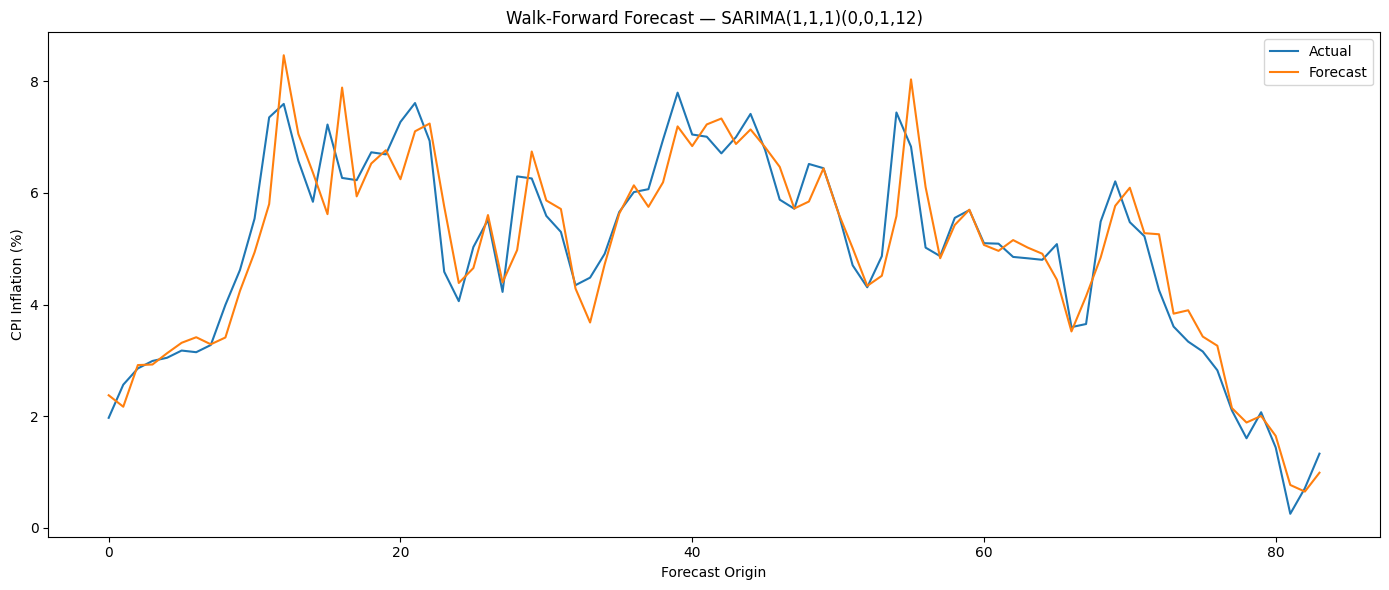

In [9]:
import matplotlib.pyplot as plt

best_forecasts = forecast_objects[best_model_name]

plt.figure(figsize=(14, 6))

plt.plot(
    best_forecasts.index,
    best_forecasts["actual"],
    label="Actual"
)

plt.plot(
    best_forecasts.index,
    best_forecasts["forecast"],
    label="Forecast"
)

plt.title(
    f"Walk-Forward Forecast — {best_model_name}"
)

plt.xlabel("Forecast Origin")
plt.ylabel("CPI Inflation (%)")

plt.legend()
plt.tight_layout()
plt.show()

In [12]:
from pathlib import Path

processed_path = Path(
    r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\data\processed"
)

# Save model comparison
results_file = processed_path / "walk_forward_arima_sarima_results.csv"

backtest_results.to_csv(
    results_file,
    index=False
)

print("Model comparison saved successfully:")
print(results_file)
print("Exists:", results_file.exists())

Model comparison saved successfully:
C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\data\processed\walk_forward_arima_sarima_results.csv
Exists: True


In [13]:
forecast_file = processed_path / "best_walk_forward_predictions.csv"

best_forecasts.to_csv(
    forecast_file,
    index=False
)

print("\nBest-model forecasts saved successfully:")
print(forecast_file)
print("Exists:", forecast_file.exists())


Best-model forecasts saved successfully:
C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\data\processed\best_walk_forward_predictions.csv
Exists: True
